# Projeto Redes Neurais — Preparação de Datasets

Este notebook consolida a preparação final dos datasets utilizados no projeto de mestrado. O fluxo foi organizado em três blocos: abertura geral, infraestrutura compartilhada e seções padronizadas por dataset.

Em cada seção são realizadas as etapas de carregamento, inspeção, limpeza, transformação, balanceamento com CTGAN, conversão para imagens e inclusão no dicionário `datasets`, que é persistido apenas ao final para reutilização nos notebooks de modelagem.


In [101]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sdv.evaluation.single_table import evaluate_quality
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

RANDOM_STATE = 42
DATASETS_PICKLE_PATH = Path("data/datasets.pkl")

## Infraestrutura compartilhada

As funções, constantes e estruturas abaixo são reutilizadas por todas as seções de dataset deste notebook.


In [102]:
def preencher_nulos_knn_onehot(df, n_vizinhos=5):
    """
    Preenche valores nulos em um DataFrame misto usando One-Hot Encoding e KNN.
    """
    df_temp = df.copy()

    cols_cat = df_temp.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
    cols_num = df_temp.select_dtypes(
        exclude=["object", "category"]
    ).columns.tolist()

    # PASSO 1: Aplicar One-Hot Encoding mantendo os NaNs
    dfs_dummies = []

    for col in cols_cat:
        dummy = pd.get_dummies(df_temp[col], prefix=col, dtype=float)
        dummy.loc[df_temp[col].isna(), :] = np.nan

        dfs_dummies.append(dummy)

    if dfs_dummies:
        df_encoded = pd.concat([df_temp[cols_num]] + dfs_dummies, axis=1)
    else:
        df_encoded = df_temp[cols_num]

    # PASSO 2: Aplicar o KNNImputer
    imputer = KNNImputer(n_neighbors=n_vizinhos)
    df_imputado = pd.DataFrame(
        imputer.fit_transform(df_encoded),
        columns=df_encoded.columns,
        index=df_encoded.index,
    )

    # PASSO 3: Reverter o One-Hot Encoding para o texto original
    df_final = df_imputado[cols_num].copy()

    for col in cols_cat:
        cols_dummy_da_vez = [c for c in df_imputado.columns if c.startswith(f"{col}_")]
        categoria_vencedora = df_imputado[cols_dummy_da_vez].idxmax(axis=1)
        df_final[col] = categoria_vencedora.str.replace(f"{col}_", "", regex=False)

    return df_final[df.columns]


def check_missing(df: pd.DataFrame):
    """
    Verifica valores ausentes em um DataFrame e imprime um relatório no console.
    """
    missing_counts = df.isnull().sum()
    missing_percentages = (df.isnull().sum() / len(df)) * 100

    missing_df = pd.DataFrame(
        {"Missing Count": missing_counts, "Percentage (%)": missing_percentages}
    )

    missing_df = missing_df[missing_df["Missing Count"] > 0]

    if missing_df.empty:
        print("No missing values found in the dataset!")
    else:
        missing_df = missing_df.sort_values(by="Percentage (%)", ascending=False)
        missing_df["Percentage (%)"] = missing_df["Percentage (%)"].round(2)

        print("\n--- Missing Values Report ---")
        print(missing_df.to_string())


def aplicar_label_encoding(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica Label Encoding em colunas categóricas de forma estrita.
    """
    df_encoded = df.copy()

    cols_cat = df_encoded.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    if not cols_cat:
        print("Nenhuma coluna categórica encontrada para aplicar Label Encoding.")
        return df_encoded

    for col in cols_cat:
        if df_encoded[col].isna().any():
            raise ValueError(
                f"ERRO: A coluna '{col}' contém valores nulos (NaN). "
                "O Label Encoding exige que os nulos sejam preenchidos antes desta etapa."
            )

        df_encoded[col] = df_encoded[col].astype("category").cat.codes

    return df_encoded


def normalizar_min_max(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica a normalização Min-Max (escala de 0 a 1) em TODAS as colunas numéricas.
    """
    df_norm = df.copy()

    cols_num = df_norm.select_dtypes(include=["number"]).columns.tolist()

    if not cols_num:
        print("Nenhuma coluna numérica encontrada para normalizar.")
        return df_norm

    scaler = MinMaxScaler()

    df_norm[cols_num] = scaler.fit_transform(df_norm[cols_num])

    return df_norm

def converter_para_imagens_2n(df: pd.DataFrame) -> np.ndarray:
    """
    Transforma um DataFrame tabular normalizado em um array de imagens 2N x 2N.
    
    Parâmetros:
    df (pd.DataFrame): DataFrame contendo apenas dados numéricos e normalizados (0 a 1).
    
    Retorna:
    np.ndarray: Array tridimensional contendo as imagens no formato (num_amostras, 2N, 2N).
    """
    # Converte o DataFrame para um array numpy para operações matemáticas mais rápidas
    dados = df.values
    num_amostras, n_features = dados.shape
    
    # Passo 1: O artigo especifica multiplicar por 255 para criar a escala de cinza
    dados_cinza = (dados * 255).astype(np.uint8)
    
    # Lista para armazenar todas as imagens geradas
    imagens_finais = []
    
    for linha in dados_cinza:
        # Passo 2: Construir a matriz N x N com duplicação e rotação (deslizamento)
        # O np.roll rotaciona o array. Usamos -i para mover para a esquerda.
        matriz_n = np.array([np.roll(linha, -i) for i in range(n_features)])
        
        # Passo 3: Expandir para 2N x 2N copiando a matriz N x N para os 4 quadrantes
        # O np.tile repete a matriz_n 2 vezes na vertical e 2 vezes na horizontal
        matriz_2n = np.tile(matriz_n, (2, 2))
        
        imagens_finais.append(matriz_2n)
        
    return np.array(imagens_finais)

def visualizar_imagens(imagens: np.ndarray, num_imagens: int = 5):
    """
    Plota as primeiras 'num_imagens' do array para visualização.
    
    Parâmetros:
    imagens (np.ndarray): O array de imagens retornado pela função de conversão.
    num_imagens (int): Quantidade de imagens a serem exibidas lado a lado.
    """
    num_imagens = min(num_imagens, len(imagens))
    
    fig, eixos = plt.subplots(1, num_imagens, figsize=(15, 5))
    
    if num_imagens == 1:
        eixos = [eixos]
        
    for i in range(num_imagens):
        eixos[i].imshow(imagens[i], cmap='gray', vmin=0, vmax=255)
        eixos[i].set_title(f"Amostra {i}")
        eixos[i].axis('off') 
        
    plt.tight_layout()
    plt.show()

datasets = {}


def relatorio_tecnico_desbalanceamento(df: pd.DataFrame, coluna_target: str):
    """
    Gera um relatório estatístico detalhado sobre o desbalanceamento da variável alvo,
    calculando frequências absolutas, relativas e o Imbalance Ratio (IR).
    """
    if coluna_target not in df.columns:
        raise KeyError(f"A coluna '{coluna_target}' não foi encontrada no DataFrame.")
        
    target_series = df[coluna_target].dropna()
    total_amostras = len(target_series)
    
    if total_amostras == 0:
        print("A coluna alvo está completamente vazia.")
        return

    contagens = target_series.value_counts()
    proporcoes = target_series.value_counts(normalize=True)
    
    classe_majoritaria = contagens.index[0]
    classe_minoritaria = contagens.index[-1]
    ir_score = contagens[classe_majoritaria] / contagens[classe_minoritaria]
    
    relatorio_df = pd.DataFrame({
        'Frequência Absoluta (N)': contagens,
        'Frequência Relativa (%)': (proporcoes * 100).round(2)
    })
    
    relatorio_df['Frequência Relativa (%)'] = relatorio_df['Frequência Relativa (%)'].map('{:.2f}%'.format)
    
    print("=" * 60)
    print(f"RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: '{coluna_target}'")
    print("=" * 60)
    print(f"Volume Total de Dados Válidos (N): {total_amostras}")
    print(f"Número de Classes Distintas:        {len(contagens)}")
    print("-" * 60)
    print(relatorio_df.to_string())
    print("-" * 60)
    print(f"Classe Majoritária: {classe_majoritaria} (N = {contagens[classe_majoritaria]})")
    print(f"Classe Minoritária: {classe_minoritaria} (N = {contagens[classe_minoritaria]})")
    print(f"Imbalance Ratio (IR): {ir_score:.2f}")
    
    print("Diagnóstico Técnico: ", end="")
    if ir_score == 1.0:
        print("Dataset perfeitamente balanceado (IR = 1.00).")
    elif ir_score <= 1.5:
        print("Equilíbrio estatístico aceitável (IR <= 1.50).")
    elif ir_score <= 4.0:
        print("Desbalanceamento moderado (1.50 < IR <= 4.00). Recomenda-se monitorar a métrica F1-Score.")
    else:
        print("Desbalanceamento severo (IR > 4.00). Risco alto de viés indutivo para a classe majoritária.")
    print("=" * 60)
    
def balance_dataset_with_gans(train_df: pd.DataFrame, target_col: str, epochs: int = 300) -> pd.DataFrame:
    """
    Balances a dataset by training a distinct CTGAN for every minority class.
    Gracefully rescales synthetic outputs to strictly match the original Min-Max bounds.
    """
    if target_col not in train_df.columns:
        raise KeyError(f"Target column '{target_col}' not found in the DataFrame.")

    # 1. Map out the class distribution
    class_counts = train_df[target_col].value_counts()
    majority_class = class_counts.index[0]
    majority_count = class_counts.iloc[0]
    minority_classes = class_counts.index[1:]

    print("=" * 60)
    print("DATASET BALANCING INITIATED (WITH RESCALING)")
    print("=" * 60)
    print(f"Majority Class: '{majority_class}' (N = {majority_count})")
    
    if len(minority_classes) == 0:
        print("Dataset is already perfectly balanced.")
        return train_df.copy()

    # 2. Extract Original Min-Max bounds
    numerical_cols = train_df.select_dtypes(include=[np.number]).columns.drop(target_col, errors='ignore')
    real_min = train_df[numerical_cols].min()
    real_max = train_df[numerical_cols].max()

    all_dataframes = [train_df.copy()]

    # 3. Process each minority class
    for minority_class in minority_classes:
        minority_count = class_counts[minority_class]
        amount_to_generate = majority_count - minority_count
        
        if amount_to_generate <= 0:
            continue
            
        print("-" * 60)
        print(f"Processing Minority Class: '{minority_class}' | Generating: {amount_to_generate} rows")
        
        df_minority = train_df[train_df[target_col] == minority_class].drop(columns=[target_col])

        metadata = SingleTableMetadata()
        metadata.detect_from_dataframe(df_minority)

        modelo_gan = CTGANSynthesizer(metadata, epochs=epochs, verbose=True)

        print(f"Training CTGAN...")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            modelo_gan.fit(df_minority)

        synthetic_data = modelo_gan.sample(num_rows=amount_to_generate)
        
        # ==============================================================================
        # 4. Mathematical Rescaling of Synthetic Data
        # ==============================================================================
        print("Rescaling synthetic data to original Min-Max bounds...")
        for col in numerical_cols:
            if col in synthetic_data.columns:
                gan_min = synthetic_data[col].min()
                gan_max = synthetic_data[col].max()
                
                # Prevent division by zero if GAN generated a completely constant column
                if gan_max > gan_min:
                    # Normalize to 0-1 based on GAN's own bounds
                    normalized = (synthetic_data[col] - gan_min) / (gan_max - gan_min)
                    # Scale it precisely into the Real Data's bounds
                    synthetic_data[col] = normalized * (real_max[col] - real_min[col]) + real_min[col]
                else:
                    # Fallback for constant features
                    synthetic_data[col] = synthetic_data[col].clip(lower=real_min[col], upper=real_max[col])
        # ==============================================================================

        print("Evaluating structural quality...")
        quality_report = evaluate_quality(
            real_data=df_minority,
            synthetic_data=synthetic_data,
            metadata=metadata,
            verbose=False
        )
        print(f"Quality Score for '{minority_class}': {quality_report.get_score():.2%}")

        # 5. Re-insert Target
        synthetic_data[target_col] = minority_class
        all_dataframes.append(synthetic_data)

    # 6. Assemble and Shuffle
    print("\n" + "=" * 60)
    print("Concatenating and shuffling final dataset...")
    enriched_df = pd.concat(all_dataframes, ignore_index=True)
    enriched_df = enriched_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
    
    print("Final Class Distribution:")
    print(enriched_df[target_col].value_counts())
    print("=" * 60)

    return enriched_df

## Seções de datasets

Cada dataset abaixo segue o mesmo template: contexto e fonte, carregamento, inspeção inicial, limpeza e transformação, relatório de desbalanceamento, split de treino/teste, enriquecimento com CTGAN, inclusão no dicionário `datasets` e visualização representativa.


## Dataset 1 — Adult Income

Predição de renda a partir de atributos demográficos e ocupacionais.

**Fonte:** https://www.kaggle.com/datasets/wenruliu/adult-income-dataset


### Carregamento do CSV


In [103]:
df = pd.read_csv("data/adult_income.csv")
df["target"] = df["target"].str.rstrip('.')

print(f"Adult Income carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()


Adult Income carregado: 48842 linhas e 16 colunas


,Unnamed: 0,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Inspeção inicial e padronização


In [104]:
df = df.drop(columns=['Unnamed: 0', "fnlwgt", "education"])

check_missing(df)


--- Missing Values Report ---
                Missing Count  Percentage (%)
occupation                966            1.98
workclass                 963            1.97
native-country            274            0.56


### Limpeza, imputação e transformação


In [105]:
df = preencher_nulos_knn_onehot(df)
check_missing(df)

No missing values found in the dataset!


In [106]:
df = aplicar_label_encoding(df)
df = normalizar_min_max(df)

In [107]:
print(f"DataFrame normalizado: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("Prévia dos dados após transformação e normalização:")
df.head()


DataFrame normalizado: 48842 linhas e 13 colunas
Prévia dos dados após transformação e normalização:


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,0.301370,0.875,0.800000,0.666667,0.071429,0.2,1.0,1.0,0.02174,0.0,0.397959,0.951220,0.0
1,0.452055,0.750,0.800000,0.333333,0.285714,0.0,1.0,1.0,0.00000,0.0,0.122449,0.951220,0.0
2,0.287671,0.500,0.533333,0.000000,0.428571,0.2,1.0,1.0,0.00000,0.0,0.397959,0.951220,0.0
3,0.493151,0.500,0.400000,0.333333,0.428571,0.0,0.5,1.0,0.00000,0.0,0.397959,0.951220,0.0
4,0.150685,0.500,0.800000,0.333333,0.714286,1.0,0.5,0.0,0.00000,0.0,0.397959,0.121951,0.0


### Relatório de desbalanceamento


In [108]:
relatorio_tecnico_desbalanceamento(df,"target")

RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: 'target'
Volume Total de Dados Válidos (N): 48842
Número de Classes Distintas:        2
------------------------------------------------------------
        Frequência Absoluta (N) Frequência Relativa (%)
target                                                 
0.0                       37155                  76.07%
1.0                       11687                  23.93%
------------------------------------------------------------
Classe Majoritária: 0.0 (N = 37155)
Classe Minoritária: 1.0 (N = 11687)
Imbalance Ratio (IR): 3.18
Diagnóstico Técnico: Desbalanceamento moderado (1.50 < IR <= 4.00). Recomenda-se monitorar a métrica F1-Score.


### Split de treino/teste


In [109]:
train_df, test_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42,
    stratify=df['target']
)

### Enriquecimento com CTGAN


In [110]:
train_df_enriched = balance_dataset_with_gans(train_df,"target")

DATASET BALANCING INITIATED (WITH RESCALING)
Majority Class: '0.0' (N = 29724)
------------------------------------------------------------
Processing Minority Class: '1.0' | Generating: 20375 rows
Training CTGAN...


/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-0.41) | Discrim. (-0.18): 100%|██████████| 300/300 [01:50<00:00,  2.71it/s]


Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '1.0': 74.85%

Concatenating and shuffling final dataset...
Final Class Distribution:
target
0.0    29724
1.0    29724
Name: count, dtype: int64


### Inclusão no dicionário `datasets`


In [111]:
datasets["adult income"] = {
    "X_train": train_df.drop(columns=["target"]),
    "X_test": test_df.drop(columns=["target"]),
    "X_train_enriched": train_df_enriched.drop(columns=["target"]),
    "y_train_enriched": train_df_enriched["target"],
    "y_train": train_df["target"],
    "y_test": test_df["target"],
    "X_train_images": converter_para_imagens_2n(train_df.drop(columns=["target"])),
    "X_train_images_enriched": converter_para_imagens_2n(
        train_df_enriched.drop(columns=["target"])
    ),
    "X_test_images": converter_para_imagens_2n(test_df.drop(columns=["target"])),
}

### Visualização representativa das imagens


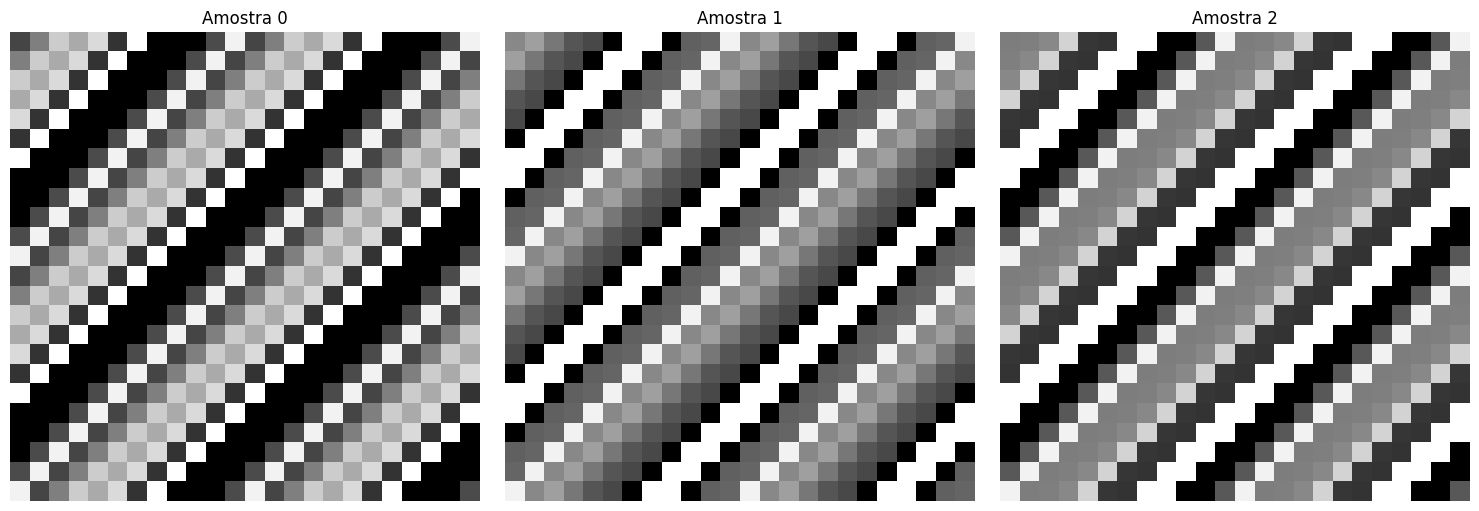

In [112]:
visualizar_imagens(datasets["adult income"]["X_train_images"], num_imagens=3)

## Dataset 2 — Student Success

Predição de evasão, permanência e conclusão acadêmica no ensino superior.

**Fonte:** https://archive.ics.uci.edu/dataset/320/student+performance


### Carregamento do CSV


In [113]:
df = pd.read_csv("data/student_success.csv")

print(f"Student Success carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()


Student Success carregado: 4424 linhas e 38 colunas


,Unnamed: 0,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,0,1,17,5,171,1,1,122.0,1,19,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,1,15,1,9254,1,1,160.0,1,1,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,2,1,1,5,9070,1,1,122.0,1,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,3,1,17,2,9773,1,1,122.0,1,38,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,4,2,39,1,8014,0,1,100.0,1,37,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Inspeção inicial e padronização


In [114]:
df = df.drop(columns=['Unnamed: 0'])
check_missing(df)

No missing values found in the dataset!


### Limpeza, imputação e transformação


In [115]:
df = aplicar_label_encoding(df)
df = normalizar_min_max(df)

In [116]:
print(f"DataFrame normalizado: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("Prévia dos dados após transformação e normalização:")
df.head()


DataFrame normalizado: 4424 linhas e 37 colunas
Prévia dos dados após transformação e normalização:


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,0.0,0.285714,0.555556,0.013858,1.0,0.0,0.284211,0.0,0.418605,0.255814,...,0.0,0.00000,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182,0.0
1,0.0,0.250000,0.111111,0.925989,1.0,0.0,0.684211,0.0,0.000000,0.046512,...,0.0,0.26087,0.181818,0.30,0.735897,0.0,0.732558,0.111111,0.640687,1.0
2,0.0,0.000000,0.555556,0.907512,1.0,0.0,0.284211,0.0,0.837209,0.837209,...,0.0,0.26087,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182,0.0
3,0.0,0.285714,0.222222,0.978108,1.0,0.0,0.284211,0.0,0.860465,0.837209,...,0.0,0.26087,0.303030,0.25,0.667692,0.0,0.209302,0.000000,0.124174,1.0
4,0.2,0.678571,0.111111,0.801466,0.0,0.0,0.052632,0.0,0.837209,0.860465,...,0.0,0.26087,0.181818,0.30,0.700000,0.0,0.732558,0.111111,0.640687,1.0


### Relatório de desbalanceamento


In [117]:
relatorio_tecnico_desbalanceamento(df,"target")

RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: 'target'
Volume Total de Dados Válidos (N): 4424
Número de Classes Distintas:        3
------------------------------------------------------------
        Frequência Absoluta (N) Frequência Relativa (%)
target                                                 
1.0                        2209                  49.93%
0.0                        1421                  32.12%
0.5                         794                  17.95%
------------------------------------------------------------
Classe Majoritária: 1.0 (N = 2209)
Classe Minoritária: 0.5 (N = 794)
Imbalance Ratio (IR): 2.78
Diagnóstico Técnico: Desbalanceamento moderado (1.50 < IR <= 4.00). Recomenda-se monitorar a métrica F1-Score.


### Split de treino/teste


In [118]:
train_df, test_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42,
    stratify=df['target']
)

### Enriquecimento com CTGAN


In [119]:
train_df_enriched = balance_dataset_with_gans(train_df,"target")

DATASET BALANCING INITIATED (WITH RESCALING)
Majority Class: '1.0' (N = 1767)
------------------------------------------------------------
Processing Minority Class: '0.0' | Generating: 630 rows
Training CTGAN...


/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-4.00) | Discrim. (-0.13): 100%|██████████| 300/300 [00:23<00:00, 12.82it/s]


Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '0.0': 79.11%
------------------------------------------------------------
Processing Minority Class: '0.5' | Generating: 1132 rows
Training CTGAN...


/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-2.44) | Discrim. (-0.21): 100%|██████████| 300/300 [00:11<00:00, 25.81it/s]


Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '0.5': 77.94%

Concatenating and shuffling final dataset...
Final Class Distribution:
target
0.0    1767
0.5    1767
1.0    1767
Name: count, dtype: int64


### Inclusão no dicionário `datasets`


In [120]:
datasets["student"] = {
    "X_train": train_df.drop(columns=["target"]),
    "X_test": test_df.drop(columns=["target"]),
    "X_train_enriched": train_df_enriched.drop(columns=["target"]),
    "y_train_enriched": train_df_enriched["target"],
    "y_train": train_df["target"],
    "y_test": test_df["target"],
    "X_train_images": converter_para_imagens_2n(train_df.drop(columns=["target"])),
    "X_train_images_enriched": converter_para_imagens_2n(
        train_df_enriched.drop(columns=["target"])
    ),
    "X_test_images": converter_para_imagens_2n(test_df.drop(columns=["target"])),
}

### Visualização representativa das imagens


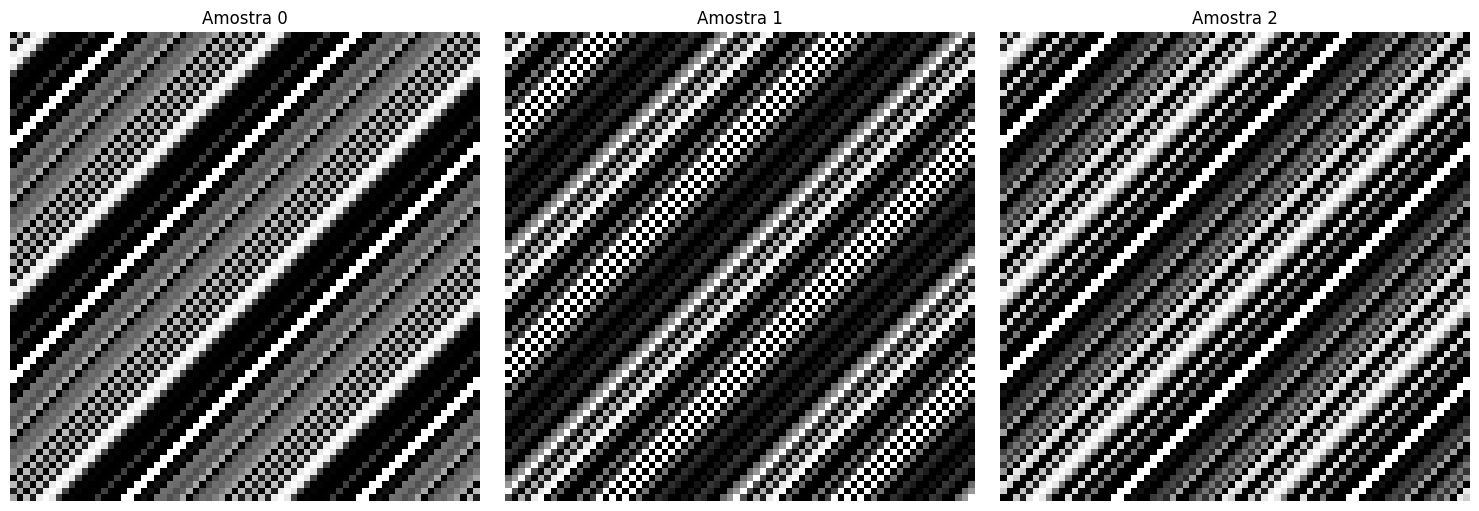

In [121]:
visualizar_imagens(datasets["student"]["X_train_images"], num_imagens=3)

## Dataset 3 — Statlog (Shuttle)

Classificação multiclasse do dataset Shuttle da coleção Statlog.

**Fonte:** https://archive.ics.uci.edu/dataset/148/statlog%2Bshuttle


### Carregamento do CSV


In [122]:
df = pd.read_csv("data/statlog.csv")

print(f"Statlog (Shuttle) carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()


Statlog (Shuttle) carregado: 58000 linhas e 10 colunas


,Unnamed: 0,Unnamed: 1,Rad Flow,Fpv Close,Fpv Open,High,Bypass,Bpv Close,Bpv Open,target
0,50,21,77,0,28,0,27,48,22,2
1,55,0,92,0,0,26,36,92,56,4
2,53,0,82,0,52,-5,29,30,2,1
3,37,0,76,0,28,18,40,48,8,1
4,37,0,79,0,34,-26,43,46,2,1


### Inspeção inicial e padronização


In [123]:
df = df.drop(columns=['Unnamed: 0','Unnamed: 1'])
check_missing(df)

No missing values found in the dataset!


### Limpeza, imputação e transformação


In [124]:
df = aplicar_label_encoding(df)
df = normalizar_min_max(df)

Nenhuma coluna categórica encontrada para aplicar Label Encoding.


In [125]:
print(f"DataFrame normalizado: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("Prévia dos dados após transformação e normalização:")
df.head()


DataFrame normalizado: 58000 linhas e 8 colunas
Prévia dos dados após transformação e normalização:


,Rad Flow,Fpv Close,Fpv Open,High,Bypass,Bpv Close,Bpv Open,target
0,0.437500,0.507015,0.346154,0.638117,0.490196,0.643660,0.607717,0.166667
1,0.554688,0.507015,0.301282,0.638737,0.549020,0.714286,0.662379,0.500000
2,0.476562,0.507015,0.384615,0.637997,0.503268,0.614767,0.575563,0.000000
3,0.429688,0.507015,0.346154,0.638546,0.575163,0.643660,0.585209,0.000000
4,0.453125,0.507015,0.355769,0.637496,0.594771,0.640449,0.575563,0.000000


### Relatório de desbalanceamento


In [126]:
relatorio_tecnico_desbalanceamento(df,"target")

RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: 'target'
Volume Total de Dados Válidos (N): 58000
Número de Classes Distintas:        7
------------------------------------------------------------
          Frequência Absoluta (N) Frequência Relativa (%)
target                                                   
0.000000                    45586                  78.60%
0.500000                     8903                  15.35%
0.666667                     3267                   5.63%
0.333333                      171                   0.29%
0.166667                       50                   0.09%
1.000000                       13                   0.02%
0.833333                       10                   0.02%
------------------------------------------------------------
Classe Majoritária: 0.0 (N = 45586)
Classe Minoritária: 0.8333333333333334 (N = 10)
Imbalance Ratio (IR): 4558.60
Diagnóstico Técnico: Desbalanceamento severo (IR > 4.00). Risco alto de viés indutivo para a classe 

### Split de treino/teste


In [127]:
train_df, test_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42,
    stratify=df['target']
)

### Enriquecimento com CTGAN


In [128]:
train_df_enriched = balance_dataset_with_gans(train_df,"target")

DATASET BALANCING INITIATED (WITH RESCALING)
Majority Class: '0.0' (N = 36469)
------------------------------------------------------------
Processing Minority Class: '0.5' | Generating: 29347 rows
Training CTGAN...


/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (0.16) | Discrim. (-0.08): 100%|██████████| 300/300 [00:46<00:00,  6.47it/s] 


Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '0.5': 59.81%
------------------------------------------------------------
Processing Minority Class: '0.6666666666666666' | Generating: 33855 rows
Training CTGAN...


/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-0.46) | Discrim. (-0.03): 100%|██████████| 300/300 [00:16<00:00, 18.73it/s]


Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '0.6666666666666666': 65.34%
------------------------------------------------------------
Processing Minority Class: '0.33333333333333337' | Generating: 36332 rows
Training CTGAN...


...

Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '0.16666666666666666': 60.37%
------------------------------------------------------------
Processing Minority Class: '0.9999999999999999' | Generating: 36459 rows
Training CTGAN...


Gen. (0.18) | Discrim. (-0.21): 100%|██████████| 300/300 [00:03<00:00, 93.76it/s] 
/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '0.9999999999999999': 55.29%
------------------------------------------------------------
Processing Minority Class: '0.8333333333333334' | Generating: 36461 rows
Training CTGAN...


Gen. (-0.05) | Discrim. (-0.02): 100%|██████████| 300/300 [00:03<00:00, 91.46it/s]


Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '0.8333333333333334': 55.63%

Concatenating and shuffling final dataset...
Final Class Distribution:
target
0.166667    36469
0.666667    36469
1.000000    36469
0.500000    36469
0.833333    36469
0.333333    36469
0.000000    36469
Name: count, dtype: int64


### Inclusão no dicionário `datasets`


In [129]:
datasets["statlog"] = {
    "X_train": train_df.drop(columns=["target"]),
    "X_test": test_df.drop(columns=["target"]),
    "X_train_enriched": train_df_enriched.drop(columns=["target"]),
    "y_train_enriched": train_df_enriched["target"],
    "y_train": train_df["target"],
    "y_test": test_df["target"],
    "X_train_images": converter_para_imagens_2n(train_df.drop(columns=["target"])),
    "X_train_images_enriched": converter_para_imagens_2n(
        train_df_enriched.drop(columns=["target"])
    ),
    "X_test_images": converter_para_imagens_2n(test_df.drop(columns=["target"])),
}

### Visualização representativa das imagens


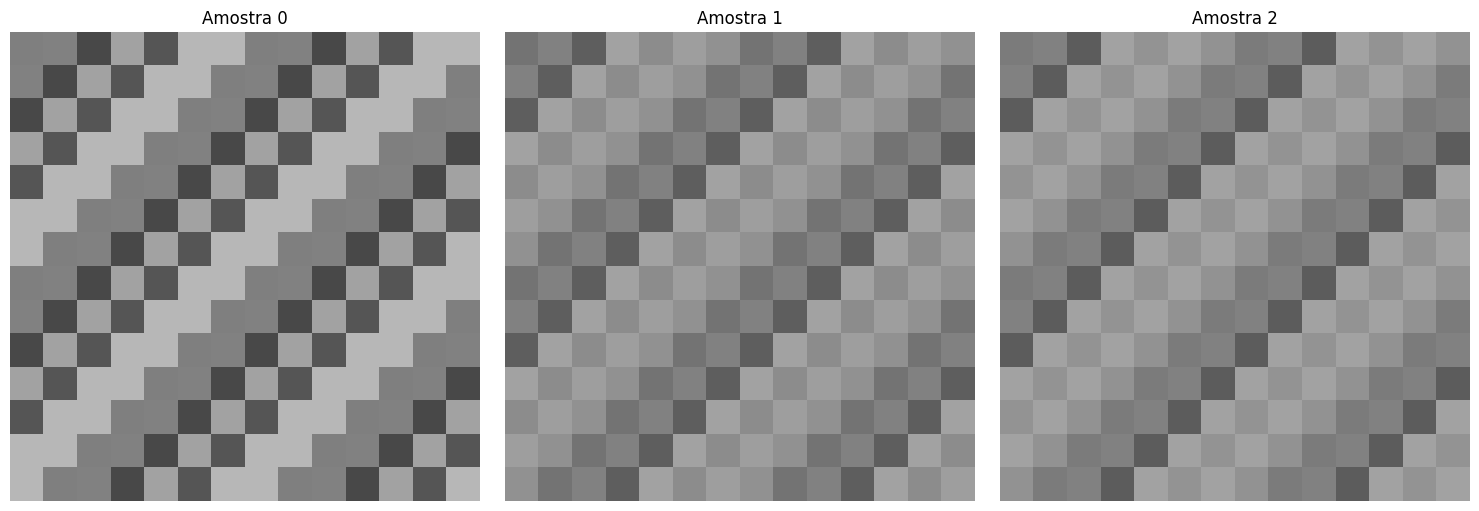

In [130]:
visualizar_imagens(datasets["statlog"]["X_train_images"], num_imagens=3)

## Dataset 4 — AI4I Maintenance

Predição de falhas em cenário de manutenção preditiva industrial.

**Fonte:** https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset


### Carregamento do CSV


In [131]:
df = pd.read_csv("data/maintenance.csv")

print(f"AI4I Maintenance carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()


AI4I Maintenance carregado: 10000 linhas e 8 colunas


,Unnamed: 0,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,target
0,0,M,298.1,308.6,1551,42.8,0,0
1,1,L,298.2,308.7,1408,46.3,3,0
2,2,L,298.1,308.5,1498,49.4,5,0
3,3,L,298.2,308.6,1433,39.5,7,0
4,4,L,298.2,308.7,1408,40.0,9,0


### Inspeção inicial e padronização


In [132]:
df = df.drop(columns=['Unnamed: 0'])
check_missing(df)

No missing values found in the dataset!


### Limpeza, imputação e transformação


In [133]:
df = aplicar_label_encoding(df)
df = normalizar_min_max(df)

In [134]:
print(f"DataFrame normalizado: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("Prévia dos dados após transformação e normalização:")
df.head()


DataFrame normalizado: 10000 linhas e 7 colunas
Prévia dos dados após transformação e normalização:


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,target
0,1.0,0.304348,0.358025,0.222934,0.535714,0.000000,0.0
1,0.5,0.315217,0.370370,0.139697,0.583791,0.011858,0.0
2,0.5,0.304348,0.345679,0.192084,0.626374,0.019763,0.0
3,0.5,0.315217,0.358025,0.154249,0.490385,0.027668,0.0
4,0.5,0.315217,0.370370,0.139697,0.497253,0.035573,0.0


### Relatório de desbalanceamento


In [135]:
relatorio_tecnico_desbalanceamento(df,"target")

RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: 'target'
Volume Total de Dados Válidos (N): 10000
Número de Classes Distintas:        2
------------------------------------------------------------
        Frequência Absoluta (N) Frequência Relativa (%)
target                                                 
0.0                        9661                  96.61%
1.0                         339                   3.39%
------------------------------------------------------------
Classe Majoritária: 0.0 (N = 9661)
Classe Minoritária: 1.0 (N = 339)
Imbalance Ratio (IR): 28.50
Diagnóstico Técnico: Desbalanceamento severo (IR > 4.00). Risco alto de viés indutivo para a classe majoritária.


### Split de treino/teste


In [136]:
train_df, test_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42,
    stratify=df['target']
)

### Enriquecimento com CTGAN


In [137]:
train_df_enriched = balance_dataset_with_gans(train_df,"target")

DATASET BALANCING INITIATED (WITH RESCALING)
Majority Class: '0.0' (N = 7729)
------------------------------------------------------------
Processing Minority Class: '1.0' | Generating: 7458 rows
Training CTGAN...


/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-1.50) | Discrim. (-0.11): 100%|██████████| 300/300 [00:03<00:00, 98.05it/s]


Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '1.0': 81.49%

Concatenating and shuffling final dataset...
Final Class Distribution:
target
0.0    7729
1.0    7729
Name: count, dtype: int64


### Inclusão no dicionário `datasets`


In [138]:
datasets["maintenance"] = {
    "X_train": train_df.drop(columns=["target"]),
    "X_test": test_df.drop(columns=["target"]),
    "X_train_enriched": train_df_enriched.drop(columns=["target"]),
    "y_train_enriched": train_df_enriched["target"],
    "y_train": train_df["target"],
    "y_test": test_df["target"],
    "X_train_images": converter_para_imagens_2n(train_df.drop(columns=["target"])),
    "X_train_images_enriched": converter_para_imagens_2n(
        train_df_enriched.drop(columns=["target"])
    ),
    "X_test_images": converter_para_imagens_2n(test_df.drop(columns=["target"])),
}

### Visualização representativa das imagens


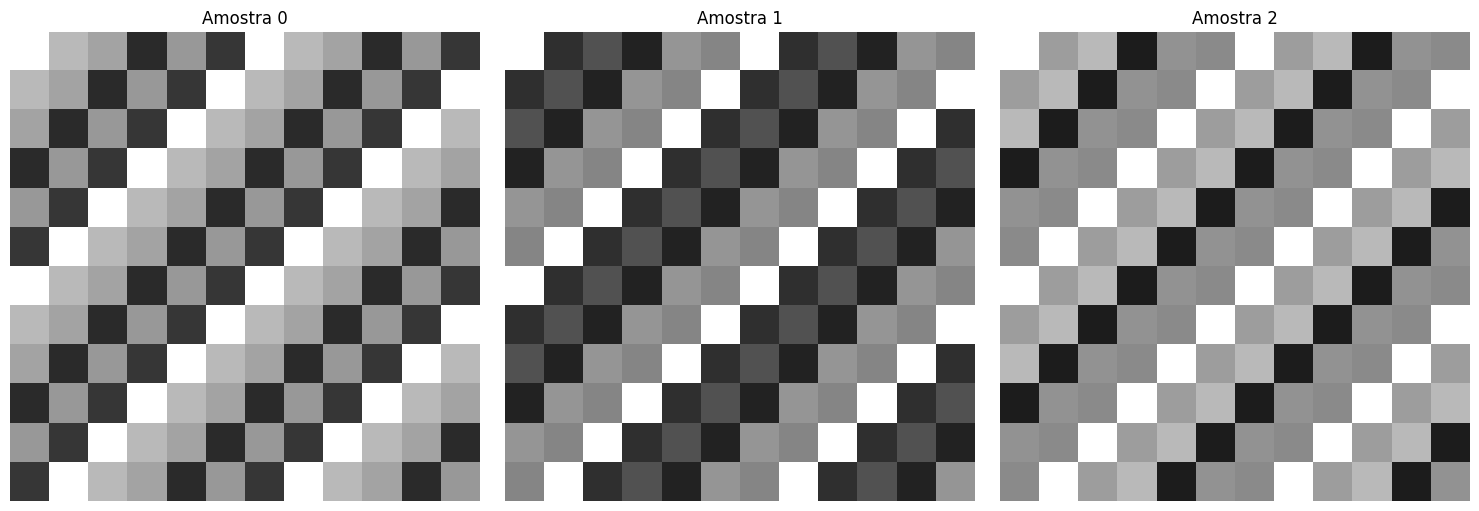

In [139]:
visualizar_imagens(datasets["maintenance"]["X_train_images"], num_imagens=3)

## Dataset 5 — Stroke

Predição de ocorrência de AVC a partir de atributos clínicos e demográficos.

**Fonte:** https://www.kaggle.com/datasets/aouatifcherdid/healthcare-dataset-stroke-data


### Carregamento do CSV


In [140]:
df = pd.read_csv("data/stroke.csv")

print(f"Stroke carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()


Stroke carregado: 5110 linhas e 12 colunas


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Inspeção inicial e padronização


In [141]:
df = df.drop(columns=['id'])
df = df.rename(columns={'stroke': 'target'})
check_missing(df)


--- Missing Values Report ---
     Missing Count  Percentage (%)
bmi            201            3.93


### Limpeza, imputação e transformação


In [142]:
df = preencher_nulos_knn_onehot(df)
check_missing(df)

No missing values found in the dataset!


In [143]:
df = aplicar_label_encoding(df)
df = normalizar_min_max(df)

In [144]:
print(f"DataFrame normalizado: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("Prévia dos dados após transformação e normalização:")
df.head()


DataFrame normalizado: 5110 linhas e 11 colunas
Prévia dos dados após transformação e normalização:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,target
0,0.5,0.816895,0.0,1.0,1.0,0.50,1.0,0.801265,0.301260,0.333333,1.0
1,0.0,0.743652,0.0,0.0,1.0,0.75,0.0,0.679023,0.254983,0.666667,1.0
2,0.5,0.975586,0.0,1.0,1.0,0.50,0.0,0.234512,0.254296,0.666667,1.0
3,0.0,0.597168,0.0,0.0,1.0,0.50,1.0,0.536008,0.276060,1.000000,1.0
4,0.0,0.963379,1.0,0.0,1.0,0.75,0.0,0.549349,0.156930,0.666667,1.0


### Relatório de desbalanceamento


In [145]:
relatorio_tecnico_desbalanceamento(df,"target")

RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: 'target'
Volume Total de Dados Válidos (N): 5110
Número de Classes Distintas:        2
------------------------------------------------------------
        Frequência Absoluta (N) Frequência Relativa (%)
target                                                 
0.0                        4861                  95.13%
1.0                         249                   4.87%
------------------------------------------------------------
Classe Majoritária: 0.0 (N = 4861)
Classe Minoritária: 1.0 (N = 249)
Imbalance Ratio (IR): 19.52
Diagnóstico Técnico: Desbalanceamento severo (IR > 4.00). Risco alto de viés indutivo para a classe majoritária.


### Split de treino/teste


In [146]:
train_df, test_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42,
    stratify=df['target']
)

### Enriquecimento com CTGAN


In [147]:
train_df_enriched = balance_dataset_with_gans(train_df,"target")

DATASET BALANCING INITIATED (WITH RESCALING)
Majority Class: '0.0' (N = 3889)
------------------------------------------------------------
Processing Minority Class: '1.0' | Generating: 3690 rows
Training CTGAN...


/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/lucasreis/Documents/projeto-redes-neurais/.venv/lib/python3.12/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-1.33) | Discrim. (0.03): 100%|██████████| 300/300 [00:04<00:00, 70.95it/s] 


Rescaling synthetic data to original Min-Max bounds...
Evaluating structural quality...
Quality Score for '1.0': 78.26%

Concatenating and shuffling final dataset...
Final Class Distribution:
target
1.0    3889
0.0    3889
Name: count, dtype: int64


### Inclusão no dicionário `datasets`


In [148]:
datasets["stroke"] = {
    "X_train": train_df.drop(columns=["target"]),
    "X_test": test_df.drop(columns=["target"]),
    "X_train_enriched": train_df_enriched.drop(columns=["target"]),
    "y_train_enriched": train_df_enriched["target"],
    "y_train": train_df["target"],
    "y_test": test_df["target"],
    "X_train_images": converter_para_imagens_2n(train_df.drop(columns=["target"])),
    "X_train_images_enriched": converter_para_imagens_2n(
        train_df_enriched.drop(columns=["target"])
    ),
    "X_test_images": converter_para_imagens_2n(test_df.drop(columns=["target"])),
}

### Visualização representativa das imagens


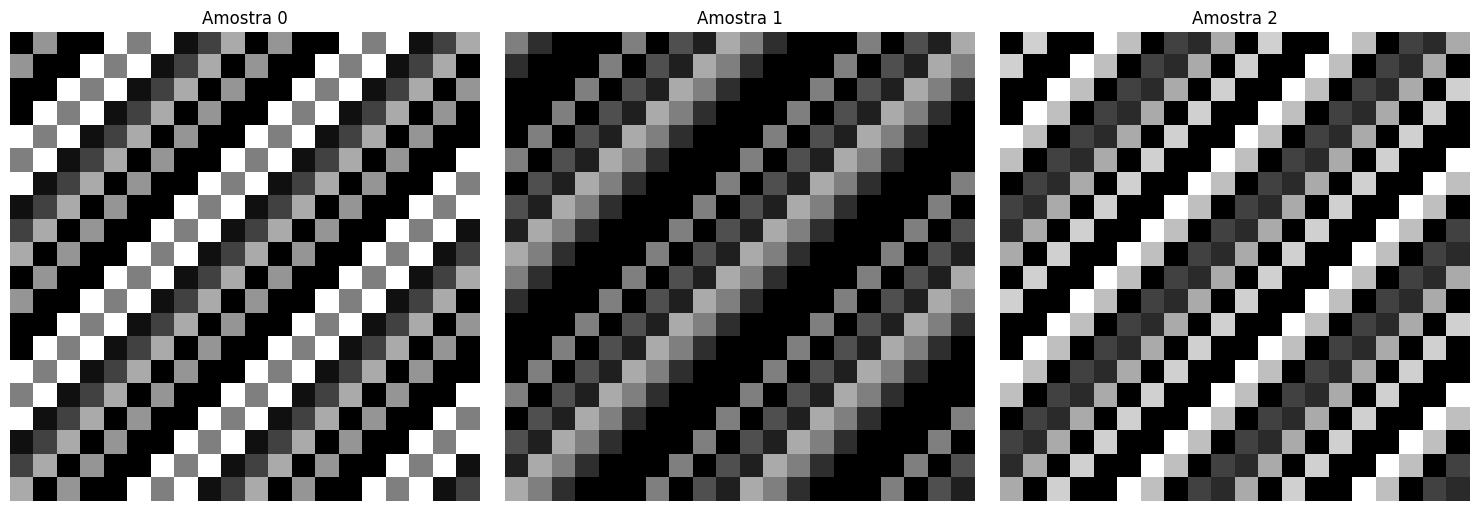

In [149]:
visualizar_imagens(datasets["stroke"]["X_train_images"], num_imagens=3)

## Consolidação final

Todos os datasets foram processados e adicionados ao dicionário `datasets`. O salvamento consolidado é realizado apenas nesta etapa final, depois que todas as seções foram concluídas.


In [150]:
DATASETS_PICKLE_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(DATASETS_PICKLE_PATH, "wb") as f:
    pickle.dump(datasets, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"datasets salvo em: {DATASETS_PICKLE_PATH}")

datasets salvo em: data/datasets.pkl


- Todos os datasets foram processados e incluídos em `datasets`.
- O dicionário consolidado foi salvo em disco em `data/datasets.pkl`.
- Esse artefato final será reutilizado pelos notebooks de modelagem.
